# MedQuAD dataset exploration
- Dataset is in `csv` format and contains 4 columns: question, answer, source and focus_area
- The total number of records is 16 412

In [1]:
import pandas as pd
ROOT = "../"

# Load CSV
df = pd.read_csv(ROOT + "dataset/medquad.csv")

print(f"Number of rows: {len(df)}")

# Display overall structure
display(df.head(10))
print(df.dtypes)

# Display a few full examples
for i in range(3):
    print(f"Example {i + 1}:")
    print(f"Question: {df.iloc[i]["question"]}")
    print(f"Answer: {df.iloc[i]["answer"]}")
    print(f"Focus Area: {df.iloc[i]["focus_area"]}")
    print("-" * 100)

Number of rows: 16412


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma
3,What are the treatments for Glaucoma ?,"Although open-angle glaucoma cannot be cured, ...",NIHSeniorHealth,Glaucoma
4,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
5,What is (are) Glaucoma ?,The optic nerve is a bundle of more than 1 mil...,NIHSeniorHealth,Glaucoma
6,What is (are) Glaucoma ?,Open-angle glaucoma is the most common form of...,NIHSeniorHealth,Glaucoma
7,Who is at risk for Glaucoma? ?,Anyone can develop glaucoma. Some people are a...,NIHSeniorHealth,Glaucoma
8,How to prevent Glaucoma ?,"At this time, we do not know how to prevent gl...",NIHSeniorHealth,Glaucoma
9,What are the symptoms of Glaucoma ?,"At first, open-angle glaucoma has no symptoms....",NIHSeniorHealth,Glaucoma


question      str
answer        str
source        str
focus_area    str
dtype: object
Example 1:
Question: What is (are) Glaucoma ?
Answer: Glaucoma is a group of diseases that can damage the eye's optic nerve and result in vision loss and blindness. While glaucoma can strike anyone, the risk is much greater for people over 60. How Glaucoma Develops  There are several different types of glaucoma. Most of these involve the drainage system within the eye. At the front of the eye there is a small space called the anterior chamber. A clear fluid flows through this chamber and bathes and nourishes the nearby tissues. (Watch the video to learn more about glaucoma. To enlarge the video, click the brackets in the lower right-hand corner. To reduce the video, press the Escape (Esc) button on your keyboard.) In glaucoma, for still unknown reasons, the fluid drains too slowly out of the eye. As the fluid builds up, the pressure inside the eye rises. Unless this pressure is controlled, it may caus

# Filtering the dataset
- Our primary goal is getting the diesease name and its corresponding symptopms. In order to achieve that, we will filter the data to only get the records that either contain any of the specified `keywords` related to symptoms in either the `question` or the `answer` field
- After filtering the data by this logic, we get 14 884 records. There are 4985 unique `focus_areas` labels, and by inspecting a few of them, we can see that they indeed correspond to disease names.

In [2]:
import pandas as pd

# Load CSV
df = pd.read_csv(ROOT + "dataset/medquad.csv")

# We only need the data that contains some information about the disease and its symptoms
keywords = [
    "symptom",
    "signs",
    "cause",
    "disease",
    "condition",
    "syndrome"
]

# Create regex pattern
pattern = "|".join(keywords)

# Filter the data by checking if any of the keywords is either in the question or the answer field
filtered = df[
    df.iloc[:, 0].str.contains(pattern, case=False, na=False) |
    df.iloc[:, 1].str.contains(pattern, case=False, na=False)
]

# Show some filtered results
for i in range(5):
    print(f"Example {i}:")
    print(f"Question: {filtered.iloc[i]["question"]}")
    print(f"Answer: {filtered.iloc[i]["answer"]}")
    print(f"Focus Area: {filtered.iloc[i]["focus_area"]}")
    print("-" * 100)


print(f"Number of records: {filtered.shape[0]}")
print(f"Number of unique focus_areas: {filtered['focus_area'].nunique()}") # This will ideally contain disease names

# Show some unique focus areas
print(f"Example of focus_areas: {filtered["focus_area"].dropna().unique()[:25]}")



Example 0:
Question: What is (are) Glaucoma ?
Answer: Glaucoma is a group of diseases that can damage the eye's optic nerve and result in vision loss and blindness. While glaucoma can strike anyone, the risk is much greater for people over 60. How Glaucoma Develops  There are several different types of glaucoma. Most of these involve the drainage system within the eye. At the front of the eye there is a small space called the anterior chamber. A clear fluid flows through this chamber and bathes and nourishes the nearby tissues. (Watch the video to learn more about glaucoma. To enlarge the video, click the brackets in the lower right-hand corner. To reduce the video, press the Escape (Esc) button on your keyboard.) In glaucoma, for still unknown reasons, the fluid drains too slowly out of the eye. As the fluid builds up, the pressure inside the eye rises. Unless this pressure is controlled, it may cause damage to the optic nerve and other parts of the eye and result in loss of vision. O

# Dataset cleanup
- Even though the filtered data contain symptoms and the disease name (focus_area), the data is not clean. We make the text lowercase, remove leading and trailing spaces, remove URLs and remove cross reference sentences
- We create column for the actual embeddeding

In [3]:
import re

def clean_text_rag(text):
    # If it's not string type
    if not isinstance(text, str):
        return ""

    text = text.lower() 
    text = re.sub(r"\s+", " ", text)  # Replace weird spacing with normal space
    
    # Remove cross reference sentences
    text = re.sub(r"(Read more|More information)[^.]*\.", "", text, flags=re.IGNORECASE)

    # Remove URLs
    text = re.sub(r"www\.\S+", "", text)
    
    return text.strip() # Remove leading and trailing white spaces

# Apply filters to each col
text_cols = filtered.select_dtypes(include="string").columns
for col in text_cols:
    filtered[col] = filtered[col].apply(clean_text_rag)

# Create newcolumn for embedding
filtered["text_for_rag"] = (
    "question: " + filtered["question"].fillna("") +
    " answer: " + filtered["answer"].fillna("")
)

display(filtered.head())

,question,answer,source,focus_area,text_for_rag
0,what is (are) glaucoma ?,glaucoma is a group of diseases that can damag...,nihseniorhealth,glaucoma,question: what is (are) glaucoma ? answer: gla...
1,what causes glaucoma ?,"nearly 2.7 million people have glaucoma, a lea...",nihseniorhealth,glaucoma,question: what causes glaucoma ? answer: nearl...
2,what are the symptoms of glaucoma ?,symptoms of glaucoma glaucoma can develop in o...,nihseniorhealth,glaucoma,question: what are the symptoms of glaucoma ? ...
3,what are the treatments for glaucoma ?,"although open-angle glaucoma cannot be cured, ...",nihseniorhealth,glaucoma,question: what are the treatments for glaucoma...
4,what is (are) glaucoma ?,glaucoma is a group of diseases that can damag...,nihseniorhealth,glaucoma,question: what is (are) glaucoma ? answer: gla...


# Create the embeddings

In [4]:
from sentence_transformers import SentenceTransformer


embedder = SentenceTransformer("pritamdeka/S-PubMedBert-MS-MARCO")
embeddings = embedder.encode(filtered["text_for_rag"].tolist(), show_progress_bar=True)

filtered["embedding"] = list(embeddings)
display(filtered.head())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/466 [00:00<?, ?it/s]

,question,answer,source,focus_area,text_for_rag,embedding
0,what is (are) glaucoma ?,glaucoma is a group of diseases that can damag...,nihseniorhealth,glaucoma,question: what is (are) glaucoma ? answer: gla...,"[-0.39189, -0.37175816, -0.44920766, -0.717546..."
1,what causes glaucoma ?,"nearly 2.7 million people have glaucoma, a lea...",nihseniorhealth,glaucoma,question: what causes glaucoma ? answer: nearl...,"[-0.38811862, -0.65294784, -0.56563157, -0.618..."
2,what are the symptoms of glaucoma ?,symptoms of glaucoma glaucoma can develop in o...,nihseniorhealth,glaucoma,question: what are the symptoms of glaucoma ? ...,"[-0.35303274, -0.45500723, -0.2737506, -0.8178..."
3,what are the treatments for glaucoma ?,"although open-angle glaucoma cannot be cured, ...",nihseniorhealth,glaucoma,question: what are the treatments for glaucoma...,"[-0.47990558, -0.23519902, -0.37848306, -0.789..."
4,what is (are) glaucoma ?,glaucoma is a group of diseases that can damag...,nihseniorhealth,glaucoma,question: what is (are) glaucoma ? answer: gla...,"[-0.3206859, -0.3648812, -0.4305763, -0.684870..."


# Create RAG
- We create a RAG with the embeddings and save it, so it can be later used in our pypeline

In [5]:
import faiss
import numpy as np

embeddings = np.array(filtered["embedding"].tolist()).astype("float32")

index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

# Save rag
import numpy as np
import pickle

faiss.write_index(index, ROOT + "rag/my_index.faiss")

# save embeddings
np.save(ROOT + "rag/embeddings.npy", embeddings)

# Create query
- We create a RAG query that returns the top k best results. The results that are returned are already from the filtered dataset

In [6]:
def query_rag(prompt, k = 5):
    query_vec = embedder.encode([prompt]).astype("float32")
    D, I = index.search(query_vec, k=k)
    results = filtered.iloc[I[0]]
    return results

# an example of the query
query_rag("Symptomps: Headache, feeling weak, sore throat, cough, really tired, runny nose")

,question,answer,source,focus_area,text_for_rag,embedding
8219,what are the symptoms of cough ?,"when you cough, mucus (a slimy substance) may ...",nhlbi,cough,question: what are the symptoms of cough ? ans...,"[-0.13024478, -0.48458353, -0.3863872, -0.4185..."
8325,what are the symptoms of pleurisy and other pl...,pleurisy the main symptom of pleurisy is a sha...,nhlbi,pleurisy and other pleural disorders,question: what are the symptoms of pleurisy an...,"[-0.20189041, -0.42842674, -0.3009936, -0.7417..."
910,what are the symptoms of small cell lung cancer ?,signs and symptoms of small cell lung cancer i...,cancergov,small cell lung cancer,question: what are the symptoms of small cell ...,"[0.018616175, -0.5351676, -0.20493786, -0.7092..."
1577,do you have information about cold and cough m...,"summary : sneezing, sore throat, a stuffy nose...",mplushealthtopics,cold and cough medicines,question: do you have information about cold a...,"[-0.3706403, -0.28104895, -0.35472324, -0.6082..."
309,what are the symptoms of copd ?,the most common symptoms of copd are a cough t...,nihseniorhealth,copd,question: what are the symptoms of copd ? answ...,"[-0.031966053, -0.52303106, -0.23881392, -0.42..."


## Create Best Matching 25 and query for it
- We created a cleaning function that is pretty much the same as the one for the RAG, but on top of that includes removal of stop_words which should improve the performance
- We then build bm25 so we can query it

In [7]:
from rank_bm25 import BM25Okapi
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

stop_words = set(stopwords.words("english"))

def clean_text_BM25(text):
    # If it's not string type
    if not isinstance(text, str):
        return ""

    text = text.lower() 
    text = re.sub(r"\s+", " ", text)  # Replace weird spacing with normal space
    
    # Remove cross reference sentences
    text = re.sub(r"(Read more|More information)[^.]*\.", "", text, flags=re.IGNORECASE)

    # Remove URLs
    text = re.sub(r"www\.\S+", "", text)

    text = text.strip() # Remove leading and trailing white spaces

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)


# Create newcolumn for embedding
filtered["text_for_bm25"] = (filtered["answer"].apply(clean_text_BM25))
filtered.to_csv(ROOT + "dataset/medquad_filtered.csv")
display(filtered.head())


# Build BM25 index on the same answer text
tokenized_corpus = [doc.lower().split() if isinstance(doc, str) else [] for doc in filtered["text_for_bm25"].tolist()]
bm25 = BM25Okapi(tokenized_corpus)

# Save BM25
with open(ROOT + "bm25/bm25.pkl", "wb") as f:
    pickle.dump(bm25, f)


[nltk_data] Downloading package punkt to /home/sagemaker-
[nltk_data]     user/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/sagemaker-
[nltk_data]     user/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/sagemaker-
[nltk_data]     user/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,question,answer,source,focus_area,text_for_rag,embedding,text_for_bm25
0,what is (are) glaucoma ?,glaucoma is a group of diseases that can damag...,nihseniorhealth,glaucoma,question: what is (are) glaucoma ? answer: gla...,"[-0.39189, -0.37175816, -0.44920766, -0.717546...",glaucoma group diseases damage eye 's optic ne...
1,what causes glaucoma ?,"nearly 2.7 million people have glaucoma, a lea...",nihseniorhealth,glaucoma,question: what causes glaucoma ? answer: nearl...,"[-0.38811862, -0.65294784, -0.56563157, -0.618...","nearly 2.7 million people glaucoma , leading c..."
2,what are the symptoms of glaucoma ?,symptoms of glaucoma glaucoma can develop in o...,nihseniorhealth,glaucoma,question: what are the symptoms of glaucoma ? ...,"[-0.35303274, -0.45500723, -0.2737506, -0.8178...",symptoms glaucoma glaucoma develop one eyes . ...
3,what are the treatments for glaucoma ?,"although open-angle glaucoma cannot be cured, ...",nihseniorhealth,glaucoma,question: what are the treatments for glaucoma...,"[-0.47990558, -0.23519902, -0.37848306, -0.789...","although open-angle glaucoma cured , usually c..."
4,what is (are) glaucoma ?,glaucoma is a group of diseases that can damag...,nihseniorhealth,glaucoma,question: what is (are) glaucoma ? answer: gla...,"[-0.3206859, -0.3648812, -0.4305763, -0.684870...",glaucoma group diseases damage eye 's optic ne...


# Query for BM25
- Query for BM25 returns top k best results. The results are in a form of pandas dataframe from the filtered dataset

In [8]:
def query_bm25(symptoms, k=5):
    # apply the same cleaning as corpus
    cleaned = clean_text_BM25(symptoms)
    tokens = cleaned.split()
    scores = bm25.get_scores(tokens)
    top_k = scores.argsort()[-k:][::-1]
    return filtered.iloc[top_k]

query_bm25("Headache, feeling weak, sore throat, cough, really tired, runny nose")

,question,answer,source,focus_area,text_for_rag,embedding,text_for_bm25
1577,do you have information about cold and cough m...,"summary : sneezing, sore throat, a stuffy nose...",mplushealthtopics,cold and cough medicines,question: do you have information about cold a...,"[-0.3706403, -0.28104895, -0.35472324, -0.6082...","summary : sneezing , sore throat , stuffy nose..."
8287,what are the symptoms of bronchitis ?,acute bronchitis acute bronchitis caused by an...,nhlbi,bronchitis,question: what are the symptoms of bronchitis ...,"[-0.16960326, -0.5738766, -0.3613927, -0.28572...",acute bronchitis acute bronchitis caused infec...
1602,what is (are) coronavirus infections ?,coronaviruses are common viruses that most peo...,mplushealthtopics,coronavirus infections,question: what is (are) coronavirus infections...,"[-0.36878505, -0.47844404, -0.3749417, -0.5285...",coronaviruses common viruses people get time l...
8219,what are the symptoms of cough ?,"when you cough, mucus (a slimy substance) may ...",nhlbi,cough,question: what are the symptoms of cough ? ans...,"[-0.13024478, -0.48458353, -0.3863872, -0.4185...","cough , mucus ( slimy substance ) may come . c..."
2336,what is (are) flu ?,flu is a respiratory infection caused by a num...,mplushealthtopics,flu,question: what is (are) flu ? answer: flu is a...,"[-0.43634576, -0.5218197, -0.4388858, -0.46935...",flu respiratory infection caused number viruse...


# Combine both queries
- We combine the both queries in order to get the top `m <= 2 * k` best results form RAG and BM25

In [9]:
def combined_query(symptoms, k=5):
    res_rag = query_rag(symptoms, k)
    res_bm25 = query_bm25(symptoms, k)

    # Combine and drop duplicate rows
    combined = pd.concat([res_rag, res_bm25]).drop_duplicates(subset="question")
    return combined

# Query example
combined_query("Headache, feeling weak, sore throat, cough, really tired, runny nose")

,question,answer,source,focus_area,text_for_rag,embedding,text_for_bm25
8219,what are the symptoms of cough ?,"when you cough, mucus (a slimy substance) may ...",nhlbi,cough,question: what are the symptoms of cough ? ans...,"[-0.13024478, -0.48458353, -0.3863872, -0.4185...","cough , mucus ( slimy substance ) may come . c..."
1577,do you have information about cold and cough m...,"summary : sneezing, sore throat, a stuffy nose...",mplushealthtopics,cold and cough medicines,question: do you have information about cold a...,"[-0.3706403, -0.28104895, -0.35472324, -0.6082...","summary : sneezing , sore throat , stuffy nose..."
1718,what is (are) sleep disorders ?,is it hard for you to fall asleep or stay asle...,mplushealthtopics,sleep disorders,question: what is (are) sleep disorders ? answ...,"[-0.3134205, -0.47546673, -0.16874737, -0.5248...",hard fall asleep stay asleep night ? wake feel...
8325,what are the symptoms of pleurisy and other pl...,pleurisy the main symptom of pleurisy is a sha...,nhlbi,pleurisy and other pleural disorders,question: what are the symptoms of pleurisy an...,"[-0.20189041, -0.42842674, -0.3009936, -0.7417...",pleurisy main symptom pleurisy sharp stabbing ...
2251,what is (are) sore throat ?,your throat is a tube that carries food to you...,mplushealthtopics,sore throat,question: what is (are) sore throat ? answer: ...,"[-0.25978607, -0.5434519, -0.39540285, -0.4960...",throat tube carries food esophagus air windpip...
8287,what are the symptoms of bronchitis ?,acute bronchitis acute bronchitis caused by an...,nhlbi,bronchitis,question: what are the symptoms of bronchitis ...,"[-0.16960326, -0.5738766, -0.3613927, -0.28572...",acute bronchitis acute bronchitis caused infec...
1602,what is (are) coronavirus infections ?,coronaviruses are common viruses that most peo...,mplushealthtopics,coronavirus infections,question: what is (are) coronavirus infections...,"[-0.36878505, -0.47844404, -0.3749417, -0.5285...",coronaviruses common viruses people get time l...
2336,what is (are) flu ?,flu is a respiratory infection caused by a num...,mplushealthtopics,flu,question: what is (are) flu ? answer: flu is a...,"[-0.43634576, -0.5218197, -0.4388858, -0.46935...",flu respiratory infection caused number viruse...


# Let's load dataset for the training the BERT
- We will use fine-tuned BERT on medical data to create a Classifier that will classify the medical urgency based on the symptoms into three categories: LOW/MEDIUM/HIGH.
- We use a two datasets for the training, each containing disease name and its symptoms
- First dataset contains 1065 records in format `description_of_symptoms` and `disease_name`. Datase can be found here [link](https://huggingface.co/datasets/gretelai/symptom_to_diagnosis)
- We use local LLM to extract only the symptoms from the description of the symptoms. Ollama with `llama3.2:3b` (or other model) is needed to be installed for this.
- The Classifier will then combine extracted user's symptoms with the best rag's symptoms and provide the urgency
- Even though we use a rather small dataset, the model should generalize since we feed it the symptoms and not the disease names. In pracitce, much larger dataset would be used to create this urgency classifier

In [10]:
import argparse
import time
import ollama

from tqdm.auto import tqdm
from datasets import load_dataset

# Dataset one processing
dataset_one = load_dataset("gretelai/symptom_to_diagnosis")
dataset_one_train = dataset_one["train"].to_pandas()
dataset_one_test = dataset_one["test"].to_pandas()
dataset_one_full = pd.concat([dataset_one_train, dataset_one_test]).reset_index(drop=True)
dataset_one_full.rename(columns={"output_text": "disease_name", "input_text": "description_of_symptoms"}, inplace=True)

tqdm.pandas()

DEFAULT_MODEL = "llama3.2:3b" 

EXTRACT_PROMPT = """Extract only the medical symptoms from the user's message.
Return a short comma-separated list of symptoms only. No explanation, no preamble."""

def extract_symptoms(user_input: str) -> str:
    response = ollama.chat(
        model=DEFAULT_MODEL,
        messages=[
            {"role": "system", "content": EXTRACT_PROMPT},
            {"role": "user", "content": user_input},
        ],
    )
    return response.message.content.strip()


dataset_one_full["symptoms"] = dataset_one_full["description_of_symptoms"].progress_map(extract_symptoms)
display(dataset_one_full.head())
print(dataset_one_full.shape)



  0%|          | 0/1065 [00:00<?, ?it/s]

,disease_name,description_of_symptoms,symptoms
0,cervical spondylosis,I've been having a lot of pain in my neck and ...,"Pain, balance problems, coordination issues, c..."
1,impetigo,I have a rash on my face that is getting worse...,"Redness, inflammation, painful blisters with c..."
2,urinary tract infection,I have been urinating blood. I sometimes feel ...,"Blood in urine, nausea upon urination, fever."
3,arthritis,I have been having trouble with my muscles and...,"tension headaches, muscle weakness, swollen jo..."
4,dengue,I have been feeling really sick. My body hurts...,"Body aches, loss of appetite, rashes on arms a..."


(1065, 3)


## Second dataset for BERT classifier
- For the second dataset we use [this](https://www.kaggle.com/datasets/choongqianzheng/disease-and-symptoms-dataset?select=DiseaseAndSymptoms.csv) dataset that cotnains Disease name and its symptoms as a features.
- This dataset contains 4920 rows

In [11]:
# Dataset two processing
dataset_two = pd.read_csv(ROOT + "dataset/DiseaseAndSymptoms.csv")
display(dataset_two.head())
# It contains columns with symptoms, we need to create one column that contains all symptoms concatenated
# Combine all the symptoms that are not empty
dataset_two["symptoms"] = dataset_two.iloc[:, 1:].apply(
    lambda row: ",".join(row.dropna().astype(str).str.replace("_", " ")),
    axis=1
)
dataset_two.rename(columns={"Disease": "disease_name"}, inplace=True)
display(dataset_two.head())
print(dataset_two.shape[0])


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,disease_name,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17,symptoms
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"itching, skin rash, nodal skin eruptions, disc..."
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"skin rash, nodal skin eruptions, dischromic ..."
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"itching, nodal skin eruptions, dischromic pat..."
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"itching, skin rash, dischromic patches"
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"itching, skin rash, nodal skin eruptions"


4920


## Combine the two datasets
- We need to combine both of the datasets and do cleanup, since some disease names are duplicated, just in a different format, so we unify them
- We are then left with 1356 unique symptoms and diseases. This will be used for the training

In [12]:
# Concatenate datset one and two to combine then
import pandas as pd

cols = ["disease_name", "symptoms"]

df_combined = pd.concat(
    [dataset_one_full[cols], dataset_two[cols]],
    ignore_index=True
)

#df_combined = dataset_one_full

display(df_combined.head())
print(df_combined.shape)
print(df_combined["disease_name"].nunique())
print(df_combined["disease_name"].unique())

# There are some duplicates, lets fix that and also some typos in the dataset
# Also in one dataset there is gerd and in the other "gastroesophageal reflux disease", even tho its the same disease

alias_map = {
    "gerd": "gastroesophageal reflux disease",
    "peptic ulcer diseae": "peptic ulcer disease",
}
df_combined["disease_name"] = (
    df_combined["disease_name"]
    .str.strip()
    .str.lower()
    .str.replace("_", " ")
    .replace(alias_map)
)

print(f"Processed {50 * "-"}")
print(df_combined.shape)
print(df_combined["disease_name"].nunique())
print(df_combined["disease_name"].unique())
print(df_combined["symptoms"].unique())

,disease_name,symptoms
0,cervical spondylosis,"Pain, balance problems, coordination issues, c..."
1,impetigo,"Redness, inflammation, painful blisters with c..."
2,urinary tract infection,"Blood in urine, nausea upon urination, fever."
3,arthritis,"tension headaches, muscle weakness, swollen jo..."
4,dengue,"Body aches, loss of appetite, rashes on arms a..."


(5985, 2)
63
<ArrowStringArray>
[                   'cervical spondylosis',
                                'impetigo',
                 'urinary tract infection',
                               'arthritis',
                                  'dengue',
                             'common cold',
                           'drug reaction',
                        'fungal infection',
                                 'malaria',
                                 'allergy',
                        'bronchial asthma',
                          'varicose veins',
                                'migraine',
                            'hypertension',
         'gastroesophageal reflux disease',
                               'pneumonia',
                               'psoriasis',
                                'diabetes',
                                'jaundice',
                             'chicken pox',
                                 'typhoid',
                    'peptic ulcer disease',


# Create urgency labels for dieseases
- We manually map urgencies labels LOW/MEDIUM/HIGH to the dieseases in the both datasets. The urgencies were mapped manually by severity index in [here](https://en.wikipedia.org/wiki/Emergency_Severity_Index). Since this is only a proof of concept, it shouldn't matter if the dieses aren't labeled 100% correctly. In real world use this would be mapped by professionals in field.

In [13]:
urgency_map = {
    # HIGH
    "heart attack": "HIGH",
    "paralysis (brain hemorrhage)": "HIGH",
    "pneumonia": "HIGH",
    "dengue": "HIGH",
    "malaria": "HIGH",
    "typhoid": "HIGH",
    "drug reaction": "HIGH",
    "hypoglycemia": "HIGH",
    "tuberculosis": "HIGH",
    "aids": "HIGH",
    "hepatitis b": "HIGH",
    "hepatitis c": "HIGH",
    "hepatitis d": "HIGH",
    "alcoholic hepatitis": "HIGH",

    # MEDIUM
    "urinary tract infection": "MEDIUM",
    "hypertension": "MEDIUM",
    "diabetes": "MEDIUM",
    "jaundice": "MEDIUM",
    "bronchial asthma": "MEDIUM",
    "peptic ulcer disease": "MEDIUM",
    "chicken pox": "MEDIUM",
    "chronic cholestasis": "MEDIUM",
    "gastroenteritis": "MEDIUM",
    "hepatitis a": "MEDIUM",
    "hepatitis e": "MEDIUM",
    "hyperthyroidism": "MEDIUM",
    "hypothyroidism": "MEDIUM",
    "dimorphic hemmorhoids(piles)": "MEDIUM",

    # LOW
    "cervical spondylosis": "LOW",
    "impetigo": "LOW",
    "arthritis": "LOW",
    "common cold": "LOW",
    "fungal infection": "LOW",
    "allergy": "LOW",
    "varicose veins": "LOW",
    "migraine": "LOW",
    "gastroesophageal reflux disease": "LOW",
    "psoriasis": "LOW",
    "osteoarthristis": "LOW",
    "(vertigo) paroymsal  positional vertigo": "LOW",
    "acne": "LOW",
}

def map_function(disease_name):
    return urgency_map[disease_name]


df_combined["urgency"] = df_combined["disease_name"].map(map_function)
display(df_combined.head())

,disease_name,symptoms,urgency
0,cervical spondylosis,"Pain, balance problems, coordination issues, c...",LOW
1,impetigo,"Redness, inflammation, painful blisters with c...",LOW
2,urinary tract infection,"Blood in urine, nausea upon urination, fever.",MEDIUM
3,arthritis,"tension headaches, muscle weakness, swollen jo...",LOW
4,dengue,"Body aches, loss of appetite, rashes on arms a...",HIGH


## Gets combined query
- We create a combined query that will be used for both the actual pipeline and the BERT classifier

In [14]:
def first_sentence(text, max_chars=150):
    if not isinstance(text, str):
        return ""
    return text.split(".")[0].strip()[:max_chars]

# TODO: maybe extact the diesease names from the answer field in medquad directly
def combined_query_processed(symptoms, k=3, max_length=200, disease_name = True):
    res_rag = query_rag(symptoms, 4)
    res_bm25 = query_bm25(symptoms, 4)

    # Combine and drop duplicate rows
    combined = pd.concat([res_rag, res_bm25]).drop_duplicates(subset="question")
    focus_areas = []
    symptoms = []
    for _, row in combined.iterrows():
        focus_areas.append(row["focus_area"])
        symptoms.append(first_sentence(row["answer"], max_length)) # TODO: answer can be replaced with text_for_rag or text_for_bm25

    string_result = []
    for i in range(len(combined)):
        if disease_name:
            string_result.append(f"Disease: {focus_areas[i]}, symptoms: {symptoms[i]}.")
        else:
            string_result.append(f"symptoms: {symptoms[i]}.")
        
    return "".join(string_result)

res = combined_query_processed("Headache, feeling weak, sore throat, cough, really tired, runny nose")
print(res)

Disease: cough, symptoms: when you cough, mucus (a slimy substance) may come up.Disease: cold and cough medicines, symptoms: summary : sneezing, sore throat, a stuffy nose, coughing -- everyone knows the symptoms of the common cold.Disease: sleep disorders, symptoms: is it hard for you to fall asleep or stay asleep through the night? do you wake up feeling tired or feel very sleepy during the day, even if you have had enough sleep? you might have a sleep disorder.Disease: pleurisy and other pleural disorders, symptoms: pleurisy the main symptom of pleurisy is a sharp or stabbing pain in your chest that gets worse when you breathe in deeply or cough or sneeze.Disease: bronchitis, symptoms: acute bronchitis acute bronchitis caused by an infection usually develops after you already have a cold or the flu.Disease: coronavirus infections, symptoms: coronaviruses are common viruses that most people get some time in their life.


- The final BERT classifier input will be the main symptoms along with the retrieved context from the RAG and BM25

In [15]:
def create_bert_data(user_input):
    query = f"Main symptoms: {user_input} + Retrieved context: {combined_query_processed(user_input, disease_name = False)}"
    return query
    
df_combined["bert_data"] = df_combined["symptoms"].progress_map(create_bert_data)
display(df_combined.head())

  0%|          | 0/5985 [00:00<?, ?it/s]

,disease_name,symptoms,urgency,bert_data
0,cervical spondylosis,"Pain, balance problems, coordination issues, c...",LOW,"Main symptoms: Pain, balance problems, coordin..."
1,impetigo,"Redness, inflammation, painful blisters with c...",LOW,"Main symptoms: Redness, inflammation, painful ..."
2,urinary tract infection,"Blood in urine, nausea upon urination, fever.",MEDIUM,"Main symptoms: Blood in urine, nausea upon uri..."
3,arthritis,"tension headaches, muscle weakness, swollen jo...",LOW,"Main symptoms: tension headaches, muscle weakn..."
4,dengue,"Body aches, loss of appetite, rashes on arms a...",HIGH,"Main symptoms: Body aches, loss of appetite, r..."


# Prepare data for training the BioBert classifier
- Let's split the data into train, val, test. Splits will be 70%, 15%, 15%
- We also need to remove duplicates, since some combinations of symptoms show multiple times and this would create polution in the training. We are left with total of 1357 training data

In [16]:
from sklearn.model_selection import train_test_split

dataset_one_symptoms = set(dataset_one_full["symptoms"].unique())
dataset_two_symptoms = set(dataset_two["symptoms"].unique())

print(f"Dataset one unique: {len(dataset_one_symptoms)}")
print(f"Dataset two unique: {len(dataset_two_symptoms)}")
print(f"Overlap between datasets: {len(dataset_one_symptoms & dataset_two_symptoms)}")
print(f"Total unique combined: {len(dataset_one_symptoms | dataset_two_symptoms)}")

# There are some overlaps in the symptoms, we only wanna keep unique ones, so there is not data polution in the training
df_combined_dedup = df_combined.drop_duplicates(subset=["symptoms"]).reset_index(drop=True)

# shuffle + split in one go
df_train, df_temp = train_test_split(
    df_combined_dedup, 
    test_size=0.3, 
    random_state=42,
    stratify=df_combined_dedup["urgency"]
)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=42,
    stratify=df_temp["urgency"]
)

print(df_train.shape)
print(df_val.shape)
print(df_test.shape)

# verify no overlap
overlap = pd.merge(df_train[["symptoms"]], df_val[["symptoms"]], on="symptoms")
print(f"Overlapping rows: {len(overlap)}")  # should be 0

Dataset one unique: 1053
Dataset two unique: 304
Overlap between datasets: 0
Total unique combined: 1357
(949, 4)
(204, 4)
(204, 4)
Overlapping rows: 0


## Create a BIO-BERT classifier
- We use BERT classifier that was finetuned on medical data. The link to the classifier can be found [here](https://huggingface.co/dmis-lab/biobert-base-cased-v1.2) and more info about its architecture is [here](https://github.com/dmis-lab/biobert). In the report, we further explore its design
- We create train the model on 15 epochs, we use optimizer AdamW (default), learning_rate 2e-5 and weight_decay=0.01. We use an early stop mechanism that will stop the training if there is no improvement to the validation accuracy after 5 epochs.
- We also create a Metrics callback, that keeps track of entire training history

In [18]:
import logging
import torch
logging.getLogger("transformers").setLevel(logging.ERROR)
torch.cuda.empty_cache()
from transformers import AutoTokenizer

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback, TrainerCallback
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

import torch

print(df_train.columns)
print(df_train["urgency"].unique())
print(df_train["urgency"].value_counts())

# Label mapping
label2id = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}
id2label = {0: "LOW", 1: "MEDIUM", 2: "HIGH"}


df_train["label"] = df_train["urgency"].map(label2id)
df_val["label"]  = df_val["urgency"].map(label2id)
df_test["label"]  = df_test["urgency"].map(label2id)

tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.2")

# Create tokenizer
def tokenize(batch):
    return tokenizer(
        batch["bert_data"],
        truncation=True,
        padding="max_length",
        max_length=512,
    )

from datasets import Dataset

# Create datasets for the BERT
train_ds = Dataset.from_pandas(df_train[["bert_data", "label"]])
val_ds  = Dataset.from_pandas(df_val[["bert_data", "label"]])
test_ds  = Dataset.from_pandas(df_test[["bert_data", "label"]])

train_ds = train_ds.map(tokenize, batched=True)
val_ds  = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Use pretraiend bio bert
model = AutoModelForSequenceClassification.from_pretrained(
    "dmis-lab/biobert-base-cased-v1.2",
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

# Use gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

# We wanna save the training history, more specifically train/val loss and train/val acc
# we also print these metrics each epoch
class PrintMetricsCallback(TrainerCallback):
    def __init__(self):
        self.history = {
            "epoch": [],
            "train_loss": [],
            "val_loss": [],
            "val_accuracy": [],
            "val_f1_macro": [],
        }
        self._train_loss = None

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs and "eval_loss" not in logs:
            self._train_loss = logs["loss"]

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        epoch = int(state.epoch)
        train_loss = self._train_loss or 0.0
        val_loss = metrics["eval_loss"]
        val_acc = metrics["eval_accuracy"]
        val_f1 = metrics["eval_f1_macro"]

        # store for plotting
        self.history["epoch"].append(epoch)
        self.history["train_loss"].append(train_loss)
        self.history["val_loss"].append(val_loss)
        self.history["val_accuracy"].append(val_acc)
        self.history["val_f1_macro"].append(val_f1)

        # print nicely
        print(
            f"Epoch {epoch:02d} | "
            f"train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f} | "
            f"val_f1: {val_f1:.4f}"
        )

metrics_callback = PrintMetricsCallback()

# Define the training arguments
training_args = TrainingArguments(
    output_dir="./biobert-triage",
    num_train_epochs=15,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_strategy="epoch",
    report_to="none",
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
)

# Create the training and train the model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=5),
        metrics_callback,
    ],
)

trainer.train()

model.save_pretrained(ROOT + "models/biobert-triage-final")
tokenizer.save_pretrained(ROOT + "models/biobert-triage-final")

Index(['disease_name', 'symptoms', 'urgency', 'bert_data'], dtype='str')
<ArrowStringArray>
['MEDIUM', 'HIGH', 'LOW']
Length: 3, dtype: str
urgency
LOW       401
MEDIUM    304
HIGH      244
Name: count, dtype: int64


Map:   0%|          | 0/949 [00:00<?, ? examples/s]

Map:   0%|          | 0/204 [00:00<?, ? examples/s]

Map:   0%|          | 0/204 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

{'eval_loss': '0.6956', 'eval_accuracy': '0.8725', 'eval_f1_macro': '0.8544', 'eval_f1_weighted': '0.8692', 'eval_runtime': '5.214', 'eval_samples_per_second': '39.12', 'eval_steps_per_second': '4.986', 'epoch': '12'}
Epoch 12 | train_loss: 0.0004 | val_loss: 0.6956 | val_acc: 0.8725 | val_f1: 0.8544


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1042', 'train_samples_per_second': '13.66', 'train_steps_per_second': '1.713', 'train_loss': '0.2187', 'epoch': '12'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../models/biobert-triage-final/tokenizer_config.json',
 '../models/biobert-triage-final/tokenizer.json')

## Visualise the training

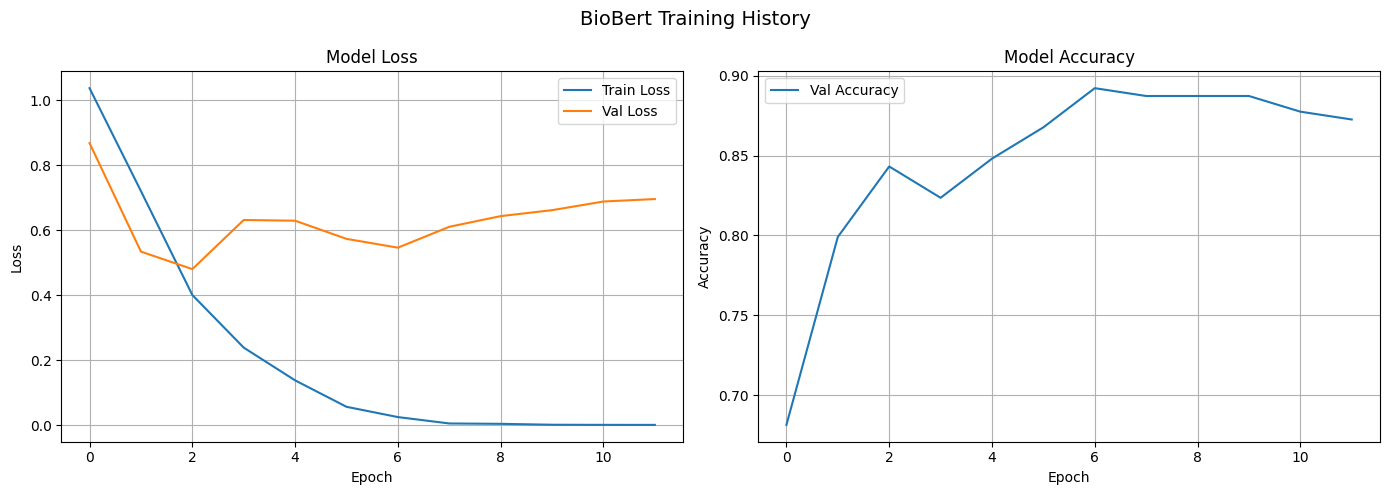

{'eval_loss': '0.003385', 'eval_accuracy': '0.9989', 'eval_f1_macro': '0.9988', 'eval_f1_weighted': '0.9989', 'eval_runtime': '23.75', 'eval_samples_per_second': '39.96', 'eval_steps_per_second': '5.01', 'epoch': '12'}
Epoch 12 | train_loss: 0.0004 | val_loss: 0.0034 | val_acc: 0.9989 | val_f1: 0.9988
Train loss: 0.0034
Train accuracy: 0.9989


{'eval_loss': '0.546', 'eval_accuracy': '0.8922', 'eval_f1_macro': '0.8721', 'eval_f1_weighted': '0.8861', 'eval_runtime': '5.16', 'eval_samples_per_second': '39.54', 'eval_steps_per_second': '5.039', 'epoch': '12'}
Epoch 12 | train_loss: 0.0004 | val_loss: 0.5460 | val_acc: 0.8922 | val_f1: 0.8721
Val loss: 0.5460
Val accuracy: 0.8922


{'eval_loss': '0.5809', 'eval_accuracy': '0.8922', 'eval_f1_macro': '0.8847', 'eval_f1_weighted': '0.8905', 'eval_runtime': '5.156', 'eval_samples_per_second': '39.57', 'eval_steps_per_second': '5.043', 'epoch': '12'}
Epoch 12 | train_loss: 0.0004 | val_loss: 0.5809 | val_acc: 0.8922 | val_f1: 0.8847
Test loss: 0.5809
Test accuracy: 0.8922


In [22]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(metrics_callback.history["train_loss"], label='Train Loss')
ax1.plot(metrics_callback.history["val_loss"], label='Val Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(metrics_callback.history["val_accuracy"], label='Val Accuracy')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.suptitle('BioBert Training History', fontsize=14)
plt.tight_layout()
plt.savefig('training_history_biobert.png', dpi=150, bbox_inches='tight')
plt.show()


train_metrics = trainer.evaluate(train_ds)
print(f"Train loss: {train_metrics['eval_loss']:.4f}")
print(f"Train accuracy: {train_metrics['eval_accuracy']:.4f}")

val_metrics = trainer.evaluate(val_ds)
print(f"Val loss: {val_metrics['eval_loss']:.4f}")
print(f"Val accuracy: {val_metrics['eval_accuracy']:.4f}")

test_metrics = trainer.evaluate(test_ds)
print(f"Test loss: {test_metrics['eval_loss']:.4f}")
print(f"Test accuracy: {test_metrics['eval_accuracy']:.4f}")


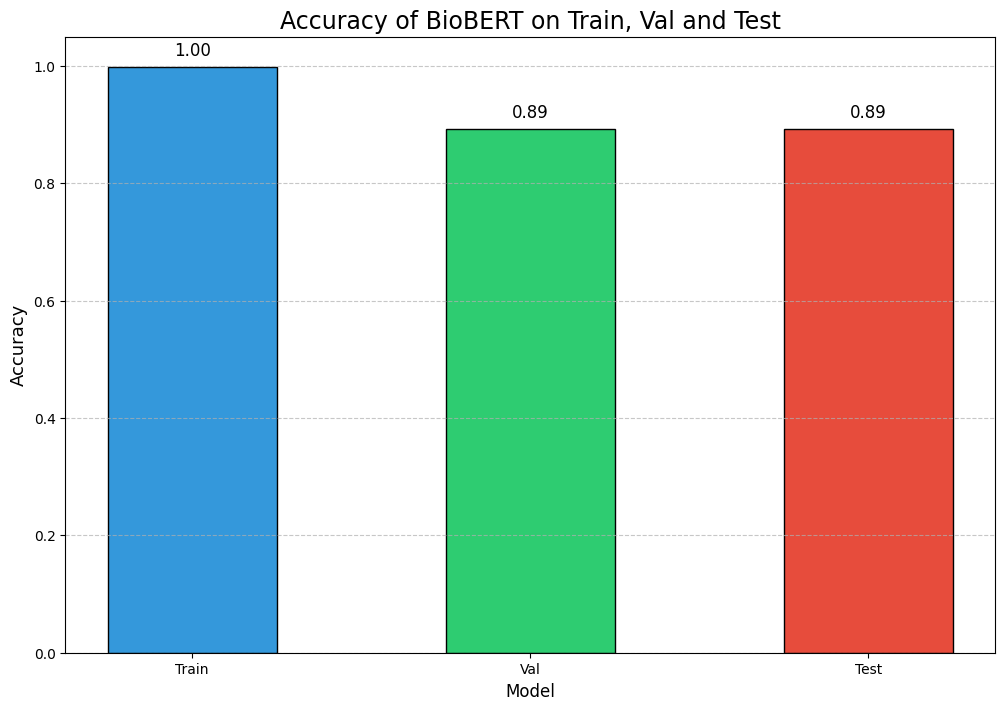

In [33]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12,8))

colors = ['#3498db', '#2ecc71', '#e74c3c']

labels = ['Train', 'Val', 'Test']
values = [train_metrics['eval_accuracy'] ,val_metrics['eval_accuracy'] , test_metrics['eval_accuracy']] 

ax.bar(labels, values, color=colors, edgecolor='black', width=0.5)

ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=13)
ax.set_title("Accuracy of BioBERT on Train, Val and Test", fontsize=17)

ax.grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(values):
    ax.text(i, value + 0.02, f'{value:.2f}', ha='center', fontsize=12)

plt.show()


## Inference
- Testing the biobert

In [31]:
def predict_urgency(user_symptoms):
    enriched = create_bert_data(user_symptoms)
    inputs = tokenizer(
        enriched,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )
    # move inputs to same device as model
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    pred = outputs.logits.argmax(-1).item()
    return id2label[pred]


# Test it

# Low urgency - basic conditions
print(f"Low urgency: {"-" * 50}")
print(predict_urgency("runny nose, mild cough, sneezing"))
print(predict_urgency("slight itching, dry skin, mild rash"))
print(predict_urgency("mild headache, feeling tired"))

# Medium urgency
print(f"Medium urgency: {"-" * 50}")
print(predict_urgency("yellowing of skin and eyes, dark urine, fatigue"))  # jaundice
print(predict_urgency("wheezing, shortness of breath, chest tightness"))  # asthma attack

# High urgency
print(f"High urgency: {"-" * 50}")
print(predict_urgency("coughing up blood, difficulty breathing, high fever, chills")) # Severe pneumonia
print(predict_urgency("sudden severe chest pain radiating to left arm, sweating, difficulty breathing")) # Heart attack
print(predict_urgency("severe abdominal pain, vomiting blood, rapid heartbeat, dizziness")) # Internal bleeding
print(predict_urgency("sudden weakness on one side of body, slurred speech, drooping face")) # Stroke


Low urgency: --------------------------------------------------
LOW
MEDIUM


MEDIUM
Medium urgency: --------------------------------------------------
MEDIUM
LOW
High urgency: --------------------------------------------------


HIGH
HIGH
HIGH


LOW
